These imports bring in all the necessary libraries for deep learning (using TensorFlow/Keras), data manipulation (using Pandas and NumPy), model evaluation, and oversampling (using SMOTE).


In [101]:
import shap
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import pandas as pd


 This section loads the CSV files containing the ECG data into Pandas DataFrames. The header=None argument ensures that the first row of data is not treated as a header (since these files don't seem to have headers).

In [102]:
# Load your preprocessed data here
# For demonstration, I'll use the previous code to load and preprocess the data


# Load the CSV files from local file system
mitbih_test = pd.read_csv('mitbih_test.csv', header=None,)
mitbih_train = pd.read_csv('mitbih_train.csv', header=None)
ptbdb_abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)
ptbdb_normal = pd.read_csv('ptbdb_normal.csv', header=None)

It separates the features (X) from the labels (y).
- X contains all columns except the last one, which holds the feature values.
- y contains the last column, which represents the labels/classes for each observation.

In [103]:

# Separate features and labels
X = mitbih_train.iloc[:, :-1].values
y = mitbih_train.iloc[:, -1].values


This splits the data into training and testing sets, ensuring that the class distribution is preserved in both sets (due to stratify=y).

In [104]:
# Initial train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data to balance the classes by generating synthetic examples of the minority class.

In [105]:


# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



This standardizes the data so that each feature has a mean of 0 and a standard deviation of 1. Standardization is applied to both the training and testing data.

In [106]:
# Standardize data
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)



This reshapes the 1D feature data into 2D matrices (with an added channel dimension) to make it compatible with Conv2D layers. The new shape (samples, 17, 11, 1) transforms each sample into a 17x11 matrix with 1 channel.

In [107]:
# Reshape data for Conv2D
X_train_reshaped = X_train_smote.reshape(-1, 17, 11, 1)
X_test_reshaped = X_test.reshape(-1, 17, 11, 1)


Summary of the Model:
- Input Shape: 17x11 matrices with 1 channel, as per your reshaped data.
- Conv2D Layers: Two blocks of Conv2D, each followed by max-pooling and dropout, allow the model to learn spatial hierarchies in the data.
- Dense Layers: The fully connected layers at the end help in making the final classification based on the features extracted by the Conv2D layers.
- Output: The model predicts one of 5 classes using a softmax activation.

In [108]:
def create_cnn_model():
    model = Sequential() #Initializes a Sequential model, which is a linear stack of layers in Keras. This means you can easily add layers one after the other.
    
    # Add convolutional layers with pooling and dropout
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(17, 11, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    
    # Adjust the kernel size to avoid negative output size
    model.add(Conv2D(64, kernel_size=(2, 2), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Flatten and add dense layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(5, activation='softmax'))  # 5 classes for MIT-BIH
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


- Stratified K-Fold Cross-Validation: This method ensures that your model is trained and validated on different subsets of the data, providing a robust measure of model performance.
- Early Stopping: Helps prevent overfitting by stopping training when no improvement is seen in validation loss.
- Session Clearing: Clears memory after each fold to ensure that training remains efficient and doesn't run into memory bottlenecks.

In [109]:
# Setup Stratified K-Fold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)# This ensures that each fold has a similar distribution of classes, which is particularly important when working with imbalanced datasets.

# Train and evaluate the model using Stratified K-Fold cross-validation
fold_no = 1
batch_size = 256  # Use a bigger batch size to fit into memory

for train_index, val_index in skf.split(X_train_smote, y_train_smote):
    print(f"Training fold {fold_no}...")
    X_train_fold, X_val_fold = X_train_reshaped[train_index], X_train_reshaped[val_index]
    y_train_fold, y_val_fold = y_train_smote[train_index], y_train_smote[val_index]

    model = create_cnn_model()

    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(X_train_fold, y_train_fold,
                        epochs=10,
                        batch_size=batch_size,
                        validation_data=(X_val_fold, y_val_fold),
                        callbacks=[early_stopping])

    # Evaluate the model on the validation set
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, batch_size=batch_size)
    print(f"Fold {fold_no} - Validation Accuracy: {val_accuracy * 100:.2f}%")

    # Clear the session to free up memory
    tf.keras.backend.clear_session()

    fold_no += 1



Training fold 1...


c:\Users\asena\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.6805 - loss: 0.8269 - val_accuracy: 0.8792 - val_loss: 0.3094
Epoch 2/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8556 - loss: 0.3873 - val_accuracy: 0.9190 - val_loss: 0.2289
Epoch 3/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.8852 - loss: 0.3145 - val_accuracy: 0.9332 - val_loss: 0.1909
Epoch 4/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8985 - loss: 0.2787 - val_accuracy: 0.9423 - val_loss: 0.1607
Epoch 5/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9094 - loss: 0.2517 - val_accuracy: 0.9503 - val_loss: 0.1439
Epoch 6/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9152 - loss: 0.2350 - val_accuracy: 0.9547 - val_loss: 0.1308
Epoch 7/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9204 - loss: 0.2226 - val_accuracy: 0.9597 - val_loss: 0.1192
Epoch 8/10
906/906 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9243 - loss: 0.2135 - 

Summary:
- Final Model Training: The model is trained on the entire dataset and validated on the test set to measure its generalization performance.
- Evaluation: The evaluation on the test set provides a final measure of model performance, including accuracy, confusion matrix, and classification metrics.
- Interpretability: The confusion matrix and classification report provide detailed insights into how well the model performs across different classes, which is crucial for understanding where the model might be struggling.

In [112]:
# Assuming 'S' is labeled as 1 and 'F' as 3 in your dataset
s_indices = np.where(y_train_smote == 1)[0]
f_indices = np.where(y_train_smote == 3)[0]

X_train_s = X_train_reshaped[s_indices]
X_train_f = X_train_reshaped[f_indices]

y_train_s = y_train_smote[s_indices]
y_train_f = y_train_smote[f_indices]

In [113]:
def augment_data(X_data, y_data, num_augments=5):
    augmented_data = []
    augmented_labels = []

    for i in range(num_augments):
        # Apply random noise
        noise = np.random.normal(0, 0.05, X_data.shape)
        X_augmented = X_data + noise
        
        augmented_data.append(X_augmented)
        augmented_labels.append(y_data)

    return np.vstack(augmented_data), np.hstack(augmented_labels)

In [114]:
# Augment the 'S' and 'F' class data
X_augmented_s, y_augmented_s = augment_data(X_train_s, y_train_s, num_augments=5)
X_augmented_f, y_augmented_f = augment_data(X_train_f, y_train_f, num_augments=5)

# Combine the augmented data with the original training data
X_train_augmented = np.vstack([X_train_reshaped, X_augmented_s, X_augmented_f])
y_train_augmented = np.hstack([y_train_smote, y_augmented_s, y_augmented_f])


In [115]:
# Evaluate the final model on the test set
test_loss, test_accuracy = final_model.evaluate(X_test_reshaped, y_test)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

# Make predictions and generate the classification report
y_pred = np.argmax(final_model.predict(X_test_reshaped), axis=-1)
classification_report_str = classification_report(y_test, y_pred, target_names=['N', 'S', 'V', 'F', 'Q'])
print("Classification Report:\n", classification_report_str)


548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9317 - loss: 0.2014
Final Test Accuracy: 93.25%
548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Classification Report:
               precision    recall  f1-score   support

           N       0.99      0.93      0.96     14494
           S       0.44      0.86      0.58       445
           V       0.85      0.93      0.89      1158
           F       0.26      0.89      0.40       128
           Q       0.95      0.98      0.97      1286

    accuracy                           0.93     17511
   macro avg       0.70      0.92      0.76     17511
weighted avg       0.96      0.93      0.94     17511



In [ ]:
# Train the model on the augmented training data
final_model = create_cnn_model()
history = final_model.fit(X_train_augmented, y_train_augmented,
                          epochs=10,
                          batch_size=batch_size,
                          validation_data=(X_test_reshaped, y_test),
                          callbacks=[early_stopping])


In [ ]:
# Train the final model on the entire training set
final_model = create_cnn_model()

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = final_model.fit(X_train_reshaped, y_train_smote,
                          epochs=10,
                          batch_size=batch_size,
                          validation_data=(X_test_reshaped, y_test),
                          class_weight=class_weight_dict,  # Apply manually set class weights
                          callbacks=[early_stopping])

# Evaluate the final model on the test set
test_loss, test_accuracy = final_model.evaluate(X_test_reshaped, y_test)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

# Make predictions on the test set
y_pred = np.argmax(final_model.predict(X_test_reshaped), axis=-1)

# Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
conf_matrix = confusion_matrix(y_test, y_pred)
#print("Confusion Matrix:\n", conf_matrix)

classification_report_str = classification_report(y_test, y_pred, target_names=['N', 'S', 'V', 'F', 'Q'])
print("Classification Report:\n", classification_report_str)



c:\Users\asena\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7038 - loss: 0.7692 - val_accuracy: 0.8372 - val_loss: 0.5047
Epoch 2/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8636 - loss: 0.3667 - val_accuracy: 0.8467 - val_loss: 0.4387
Epoch 3/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8914 - loss: 0.2950 - val_accuracy: 0.8986 - val_loss: 0.2999
Epoch 4/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9061 - loss: 0.2589 - val_accuracy: 0.8895 - val_loss: 0.3227
Epoch 5/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9124 - loss: 0.2402 - val_accuracy: 0.8970 - val_loss: 0.2979
Epoch 6/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9190 - loss: 0.2234 - val_accuracy: 0.9265 - val_loss: 0.2324
Epoch 7/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9238 - loss: 0.2104 - val_accuracy: 0.9079 - val_loss: 0.2698
Epoch 8/10
1133/1133 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9268 -

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_smote), y=y_train_smote)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("Class Weights:", class_weight_dict)


Class Weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


c:\Users\asena\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")


Shape of X_test_reshaped: (5, 17, 11, 1)


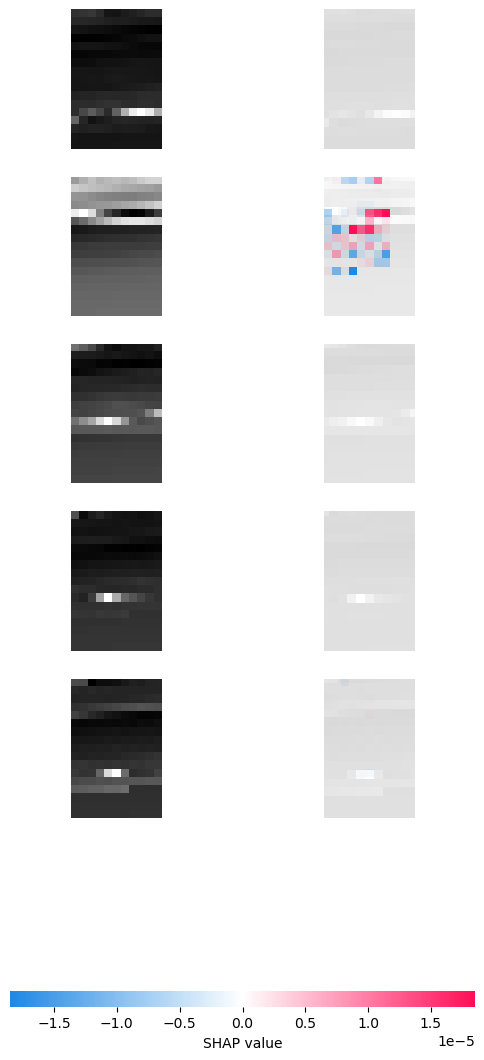

In [ ]:
# Import SHAP
# Import SHAP
import shap

# Use SHAP DeepExplainer to explain the model's predictions
background = X_train_reshaped[np.random.choice(X_train_reshaped.shape[0], 100, replace=False)]

# Note: DeepExplainer requires the model and background data
explainer = shap.DeepExplainer(final_model, background)
shap_values = explainer.shap_values(X_test_reshaped[:10])

# Check shapes
print("Shape of X_test_reshaped:", X_test_reshaped[:5].shape)
#for i, shap_val in enumerate(shap_values):
    #print(f"Shape of shap_values[{i}]:", shap_val.shape)

# Initialize JS visualization
shap.initjs()

# Visualize the SHAP values
# Note: For image plots, ensure the correct SHAP values and instances are visualized
shap.image_plot(shap_values, X_test_reshaped[:5])



Shape of X_test_s_f: (573, 17, 11, 1)
Shape of shap_values_s_f[0]: (17, 11, 1, 5)
Shape of shap_values_s_f[1]: (17, 11, 1, 5)
Shape of shap_values_s_f[2]: (17, 11, 1, 5)
Shape of shap_values_s_f[3]: (17, 11, 1, 5)
Shape of shap_values_s_f[4]: (17, 11, 1, 5)
Shape of shap_values_s_f[5]: (17, 11, 1, 5)
Shape of shap_values_s_f[6]: (17, 11, 1, 5)
Shape of shap_values_s_f[7]: (17, 11, 1, 5)
Shape of shap_values_s_f[8]: (17, 11, 1, 5)
Shape of shap_values_s_f[9]: (17, 11, 1, 5)
Shape of shap_values_s_f[10]: (17, 11, 1, 5)
Shape of shap_values_s_f[11]: (17, 11, 1, 5)
Shape of shap_values_s_f[12]: (17, 11, 1, 5)
Shape of shap_values_s_f[13]: (17, 11, 1, 5)
Shape of shap_values_s_f[14]: (17, 11, 1, 5)
Shape of shap_values_s_f[15]: (17, 11, 1, 5)
Shape of shap_values_s_f[16]: (17, 11, 1, 5)
Shape of shap_values_s_f[17]: (17, 11, 1, 5)
Shape of shap_values_s_f[18]: (17, 11, 1, 5)
Shape of shap_values_s_f[19]: (17, 11, 1, 5)
Shape of shap_values_s_f[20]: (17, 11, 1, 5)
Shape of shap_values_s_f[21

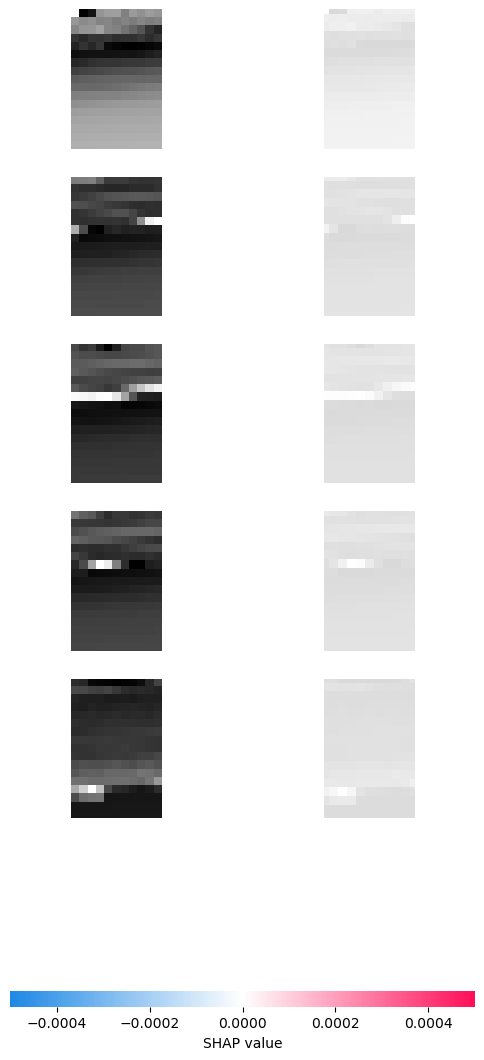

In [ ]:
import numpy as np
import shap

# Assuming 'S' and 'F' classes are labeled as 1 and 3 in your dataset

# Filter the test set for 'S' and 'F' classes
s_f_indices = np.where((y_test == 1) | (y_test == 3))[0]
X_test_s_f = X_test_reshaped[s_f_indices]
y_test_s_f = y_test[s_f_indices]

# Use SHAP DeepExplainer to explain the model's predictions for 'S' and 'F' classes
background = X_train_reshaped[np.random.choice(X_train_reshaped.shape[0], 100, replace=False)]
explainer = shap.DeepExplainer(final_model, background)
shap_values_s_f = explainer.shap_values(X_test_s_f)

# Check shapes
print("Shape of X_test_s_f:", X_test_s_f.shape)
for i, shap_val in enumerate(shap_values_s_f):
    #print(f"Shape of shap_values_s_f[{i}]:", shap_val.shape)

# Initialize JS visualization
shap.initjs()

# Visualize the SHAP values for 'S' and 'F' classes
shap.image_plot(shap_values_s_f, X_test_s_f[:5])


Shape of X_test_reshaped: (10, 17, 11, 1)


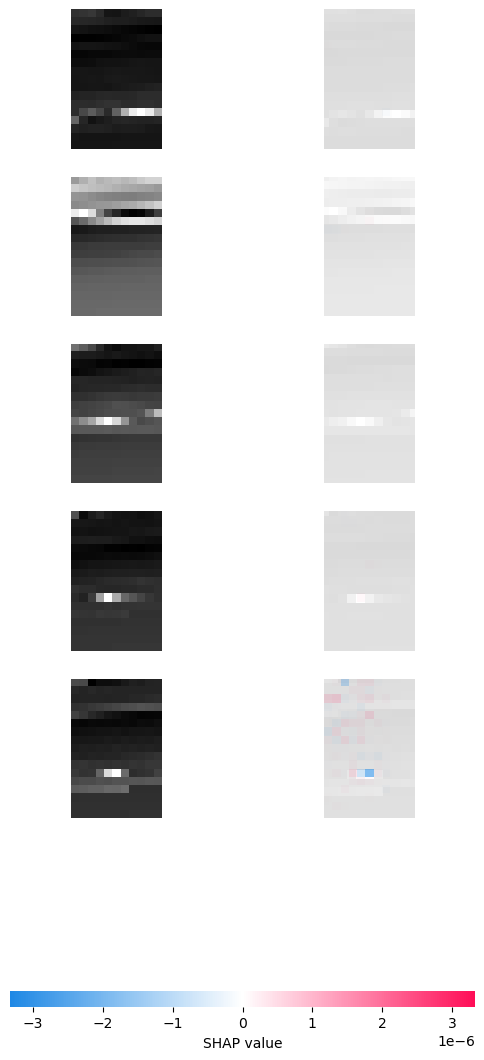

In [ ]:
import shap
import numpy as np
import tensorflow as tf

# Use SHAP to explain the model's predictions
background = X_train_reshaped[np.random.choice(X_train_reshaped.shape[0], 100, replace=False)]
explainer = shap.GradientExplainer((final_model.input, final_model.output), background)
shap_values = explainer.shap_values(X_test_reshaped[:10])

# Check shapes
print("Shape of X_test_reshaped:", X_test_reshaped[:10].shape)
print("Shape of shap_values[0]:", shap_values[0].shape)

# Aggregate SHAP values over output classes (sum over the last dimension)
shap_values_aggregated = np.sum(shap_values, axis=-1)

# Flatten the SHAP values and the test data for the force plot
shap_values_flattened = shap_values_aggregated.reshape(shap_values_aggregated.shape[0], -1)
X_test_flattened = X_test_reshaped[:10].reshape(X_test_reshaped[:10].shape[0], -1)

# Calculate the expected value (mean model output for the background dataset)
expected_value = np.mean(final_model.predict(background), axis=0)

# Visualize the SHAP values for all instances in the test set using force plot
shap.initjs()
shap.force_plot(expected_value[0], shap_values_flattened, X_test_flattened, link="logit")


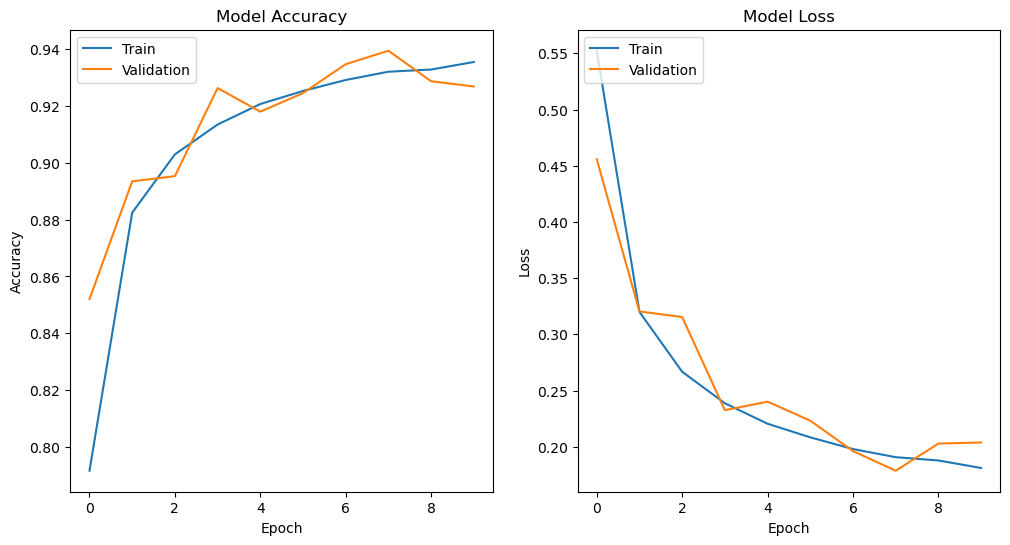

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


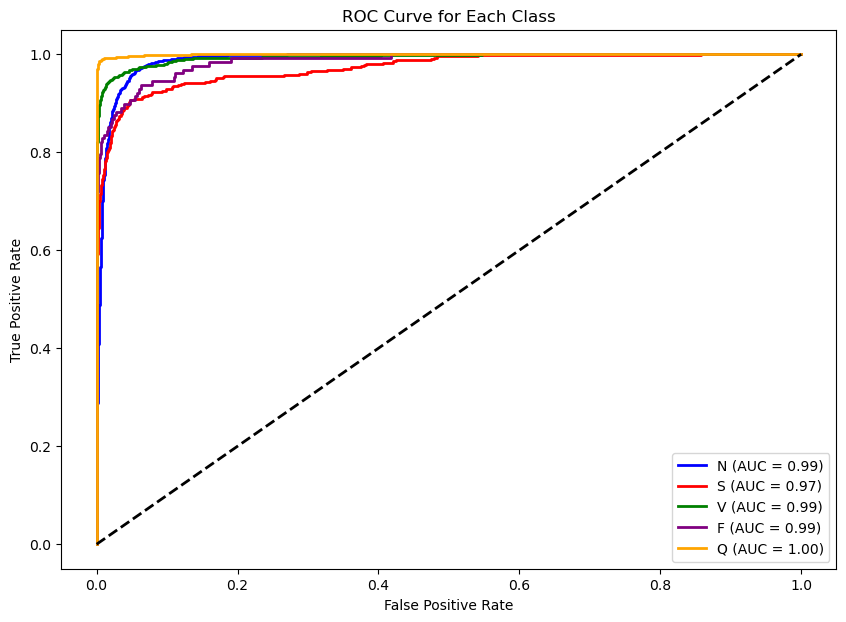

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the labels for ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
n_classes = y_test_bin.shape[1]
y_score = final_model.predict(X_test_reshaped)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'purple', 'orange']
class_names = ['N', 'S', 'V', 'F', 'Q']
for i, color, class_name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from lime import lime_image
import matplotlib.pyplot as plt

# Use LIME to explain the model's predictions
explainer = lime_image.LimeImageExplainer()

# Explain a single instance (change the index to explain different instances)
i = 0  # Index of the instance to explain
explanation = explainer.explain_instance(
    X_test_reshaped[i].reshape(17, 11),
    final_model.predict,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# Show the explanation for label 0
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)
plt.imshow(temp, cmap='gray')
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

ValueError: Error when checking input: expected conv2d_2_input to have shape (17, 11, 1) but got array with shape (17, 11, 3)